In [183]:
from datetime import datetime
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import seaborn as sns
from statsmodels.tsa.arima_model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from  statsmodels.tsa.stattools import adfuller

In [133]:
df = pd.read_csv('./data/GOOGL_2006-01-01_to_2018-01-01.csv')

In [98]:
df = df.drop('Open', axis= 1)

In [99]:
df.head()

,Date,High,Low,Close,Volume,Name
0,2006-01-03,218.05,209.32,217.83,13137450,GOOGL
1,2006-01-04,224.70,220.09,222.84,15292353,GOOGL
2,2006-01-05,226.00,220.97,225.85,10815661,GOOGL
3,2006-01-06,235.49,226.85,233.06,17759521,GOOGL
4,2006-01-09,236.94,230.70,233.68,12795837,GOOGL


([<matplotlib.axis.XTick at 0x182ecd995b0>,
 [Text(0, 0, '2006-01-03'),
  Text(300, 0, '2007-03-15'),
  Text(600, 0, '2008-05-22'),
  Text(900, 0, '2009-07-31'),
  Text(1200, 0, '2010-10-11'),
  Text(1500, 0, '2011-12-16'),
  Text(1800, 0, '2013-03-01'),
  Text(2100, 0, '2014-05-09'),
  Text(2400, 0, '2015-07-20'),
  Text(2700, 0, '2016-09-26'),
  Text(3000, 0, '2017-12-04')])

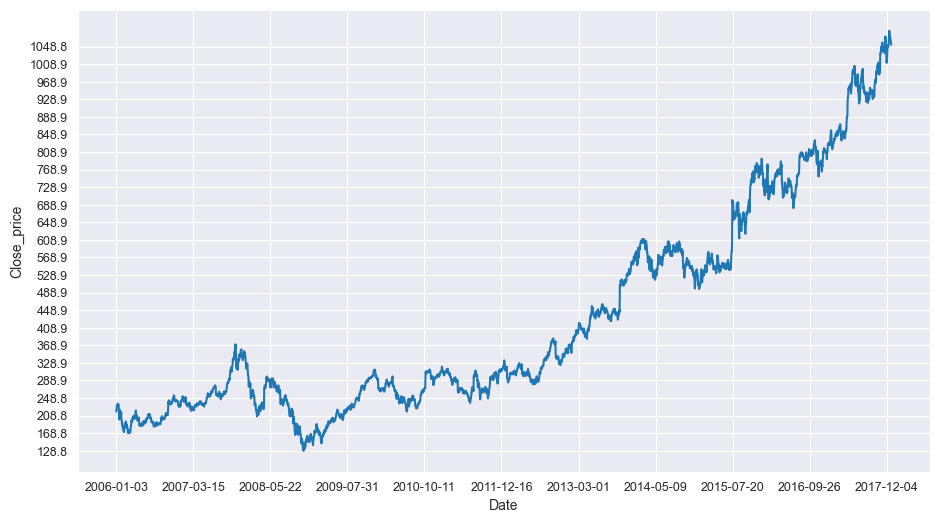

In [100]:
plt.figure(figsize= (11,6))
plt.plot(df['Date'], df['Close'])
plt.xlabel('Date')
plt.ylabel('Close_price')
plt.yticks(np.arange(df['Close'].min(), df['Close'].max(), 40),size = 9)
plt.xticks([ i for i in range(0,df.count()[0],300) ], size = 9)

Let's start our analysis with decomposition of the time series (ts)

In [101]:
decompose = seasonal_decompose( x = df['Close'].values, model = 'additive', period=800)

In [102]:
season = decompose.seasonal
trends = decompose.trend
noise = decompose.resid

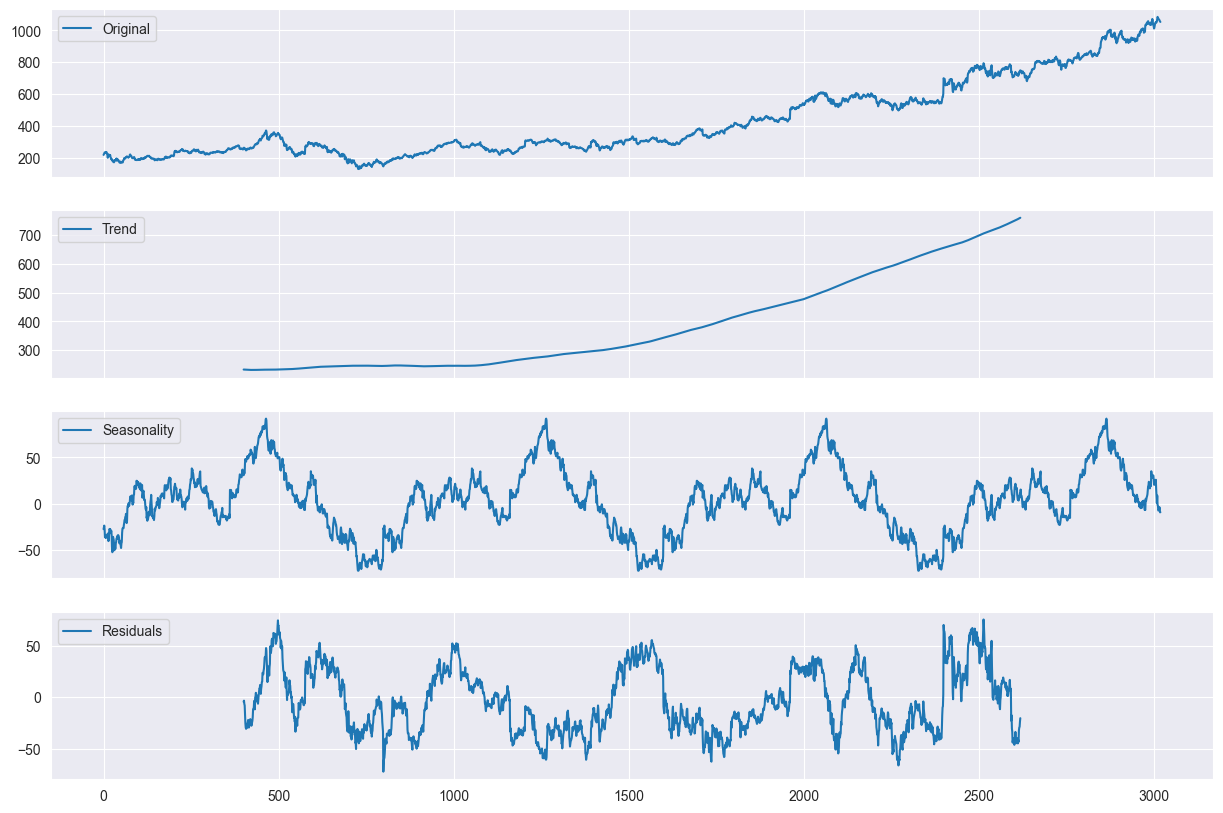

In [103]:
fig, axes = plt.subplots(4, 1, sharex=True, sharey=False)
fig.set_figheight(10)
fig.set_figwidth(15)

axes[0].plot(df['Close'].values, label='Original')
axes[0].legend(loc='upper left');

axes[1].plot(trends, label='Trend')
axes[1].legend(loc='upper left');

axes[2].plot(season, label='Seasonality')
axes[2].legend(loc='upper left');

axes[3].plot(noise, label='Residuals')
axes[3].legend(loc='upper left');

Looking at this decomposition we can see seasonal behavior of the ts, its trend and residuals (or noise)

Now let us have a look at the autocorrelation
From this we will derive, how far the next value depends on the previos one

In [139]:
df_new = df[['Date','Close']]
df_new.set_index('Date', inplace=True)

In [140]:
df_new

,Close
Date,
2006-01-03,217.83
2006-01-04,222.84
2006-01-05,225.85
2006-01-06,233.06
2006-01-09,233.68
...,...
2017-12-22,1068.86
2017-12-26,1065.85
2017-12-27,1060.20


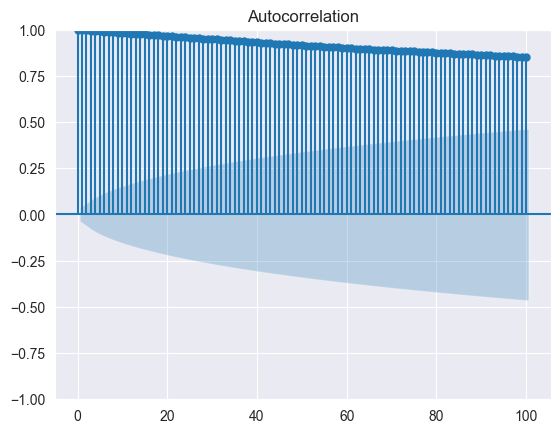

In [168]:
plot_acf(df_new, lags = 100)
plt.show()

C:\PyCharm_Prjs\course_prj\venv\lib\site-packages\statsmodels\graphics\tsaplots.py:348: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  warnings.warn(


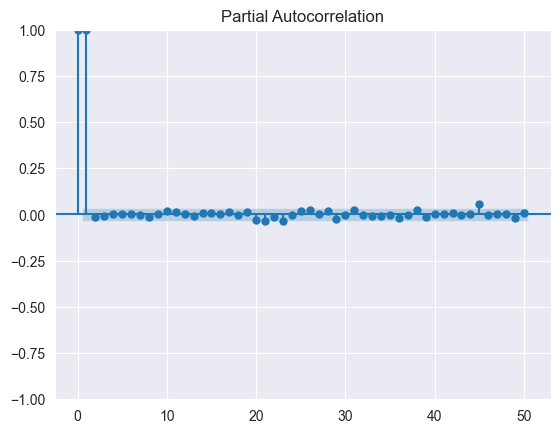

In [170]:
plot_pacf(df_new, lags = 50)
plt.show()

From the autocorr. and partial autocorr. we see obtain p and q values for the following ARIMA model. Then p is about 50-60, q is 2

Now, lets conduct the Augmented Dickey-Fuller test (ADF) and Jarque-Bera test (JB)
So, the ADF is needed to decide whether our ts is stationary or not.
Another, features ,proving nonstationarity of a ts, are differencing mean value and variance


In [201]:
adf_test = adfuller(df['Close'].values)

print('ADF:', adf_test[0])
print('p-value:', adf_test[1])

ADF: 1.3224241360302178
p-value: 0.9967315857800989


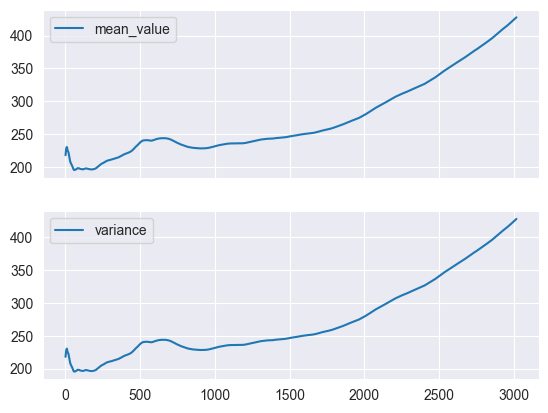

In [199]:
ig, axes = plt.subplots(2, 1, sharex=True, sharey=False)
fig.set_figheight(20)
fig.set_figwidth(15)

axes[0].plot(list(np.mean(df['Close'][:i]) for i in range (0,len(df['Close'].values))), label = 'mean_value')
axes[0].legend(loc='upper left');
axes[1].plot(list(np.mean(df['Close'][:i]) for i in range (0,len(df['Close'].values))), label = 'variance')
axes[1].legend(loc='upper left');

The more negative value of ADF and the closer p-value to 0 is, the more condfident one can be that the ts is stationary and vice versa.
So, from the results it is clear that we deal with nonstationary ts. After that we can construct the ARIMA model.